#### Figure 1: combination of overview maps showing spatial trends over two periods identified and time series of sea ice extent for pan-Arctic and Greenland Sea regions.

Figure Caption

Figure 1. Maps of Greenland Sea region of interest (black dashed line) and Fram Strait mooring locations (purple dots) with sea ice extent maxima (SIC = 0.15; blue contour) and sea-ice concentration spatial trends overlaid (shading) for a) March 1986 (1979-2015 trend) and b) March 2023 (2015-2025 trend); timeseries of March sea-ice extent with split linear trends using breakpoints identified by piecewise linear regression and bootstrap 95% confidence intervals for c) pan-Arctic region and d) Greenland Sea with sea ice extent maxima for each period marked with purple squares to highlight the years plotted in a) and b).

PART 1: CALCULATING SPATIAL TRENDS

1. Loading ERA5 data...
   Time range: 1979 to 2025
   Grid: 361 x 1440

2. Subsetting to trend calculation extent...
   Subset grid: 121 x 721

3. Extracting March sea ice concentration...
   March timesteps: 47

4. Period 1 (1979-2014):
   Timesteps: 36
  Calculating spatial trends (vectorized)...
    Valid cells: 57865 / 87241
    Slope range: -0.026197 to 0.017851 yr⁻¹
    Significant cells (p<0.05): 29986
    Mean R²: 0.152

5. Period 2 (2015-2025):
   Timesteps: 11
  Calculating spatial trends (vectorized)...
    Valid cells: 57865 / 87241
    Slope range: -0.032630 to 0.074501 yr⁻¹
    Significant cells (p<0.05): 2772
    Mean R²: 0.087

PART 2: LOADING DATA FOR PLOTTING

Loading ETOPO1 bathymetry...

Extracting March 1986 SIC...
Extracting March 2023 SIC...

Masking trends where SIC < 15%...
Data loaded successfully!

PART 3: CREATING FIGURE

Creating Panel A (1986)...
Creating Panel B (2023)...
Adding colorbars...


/tmp/ipykernel_1354611/2462291855.py:471: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.12, 1, 1])



Figure saved: ./Figure1_overview_map.png


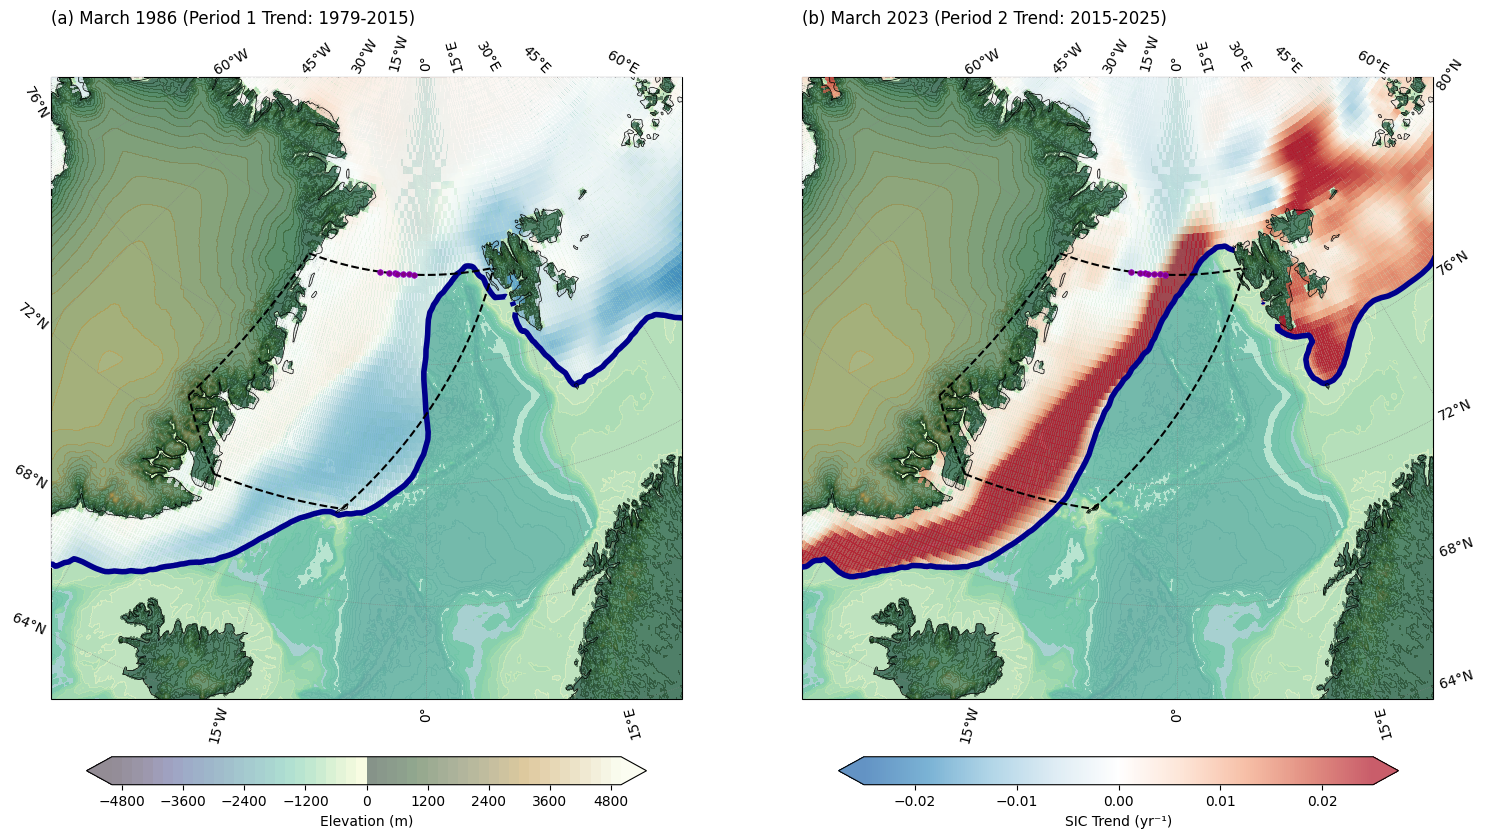


COMPLETE


In [1]:
"""
Figure 1: Greenland Sea Sea Ice Concentration and Trends - COMBINED
====================================================================
Combined script that:
1. Calculates spatial trends for March SIC (two periods)
2. Creates 2-panel overview map with trends and ice edge

Two-panel figure showing:
- Left: March 1987 SIC edge (15% contour) with 1979-2014 trends
- Right: March 2023 SIC edge (15% contour) with 2015-2025 trends

Background: ETOPO1 bathymetry
Overlays: Greenland Sea boundary, Fram Strait moorings
Trends masked where SIC < 15%
"""

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as mticker
import cmocean
import rockhound as rh
from scipy import stats

# ============================================================================
# CONFIGURATION
# ============================================================================

# File paths
ERA5_PATH = '../era5/era5_*_Arctic.nc'

# Maximum extent years (from diagnostic script)
MAX_YEAR_P1 = 1986
MAX_YEAR_P2 = 2023

# Analysis periods
PERIOD_1 = (1979, 2014)
PERIOD_2 = (2015, 2025)

# Full extent for trend calculation
TREND_EXTENT = {
    'lon_min': -90,
    'lon_max': 90,
    'lat_min': 60,
    'lat_max': 90  # Extended to North Pole
}

# Map display settings
MAP_EXTENT = [-30, 20, 65, 85]  # [lon_min, lon_max, lat_min, lat_max]
RELIEF_ALPHA = 0.5
TREND_ALPHA = 0.7
SIC_THRESHOLD = 0.15

# Colors
COLOR_BOUNDARY = 'black'
COLOR_MOORING = 'purple'  # Changed from red
COLOR_ICE_EDGE = 'darkblue'

# Greenland Sea polygon vertices
GREENLAND_SEA_COORDS = [
    (-22, 71), (-8.5, 71), (12, 79), (-21, 79), (-28, 73), (-22, 71)
]

# Fram Strait moorings
MOORINGS = {
    'F17':  -8.0,
    'F14':  -6.5,
    'F13b': -5.5,
    'F13':  -5.0,
    'F12':  -4.0,
    'F11':  -3.0,
    'F10':  -2.0,
}
MOORING_LAT = 79.0

VERTICES = {
    'NW': (-21, 79),
    'NE': (12, 79),
    'SE': (-8.5, 71),
    'SW': (-22, 71),
    'W_Mid': (-28, 73)
}

# Create custom diverging colormap: blue (negative) -> white (0) -> red (positive)
colors_trend = ['#2166ac', '#4393c3', '#92c5de', '#d1e5f0', 
                'white', 
                '#fddbc7', '#f4a582', '#d6604d', '#b2182b']
n_bins = 256
cmap_trend = LinearSegmentedColormap.from_list('red_white_blue', colors_trend, N=n_bins)

# ============================================================================
# FUNCTIONS
# ============================================================================

def calculate_spatial_trends_vectorized(data_array, time_dim='time'):
    """
    Vectorized calculation of linear trends for each grid cell.
    
    Args:
        data_array: xarray DataArray with time dimension
        time_dim: Name of time dimension
    
    Returns:
        Tuple of (slope, pvalue, rsquared) DataArrays
    """
    print("  Calculating spatial trends (vectorized)...")
    
    # Get time values and convert to numeric
    time_values = data_array[time_dim].values
    years = pd.to_datetime(time_values).year.values
    time_numeric = years - years[0]
    n_times = len(time_numeric)
    
    # Get spatial dimensions
    data = data_array.values  # shape: (time, lat, lon)
    n_lat, n_lon = data.shape[1], data.shape[2]
    
    # Reshape data: (time, space)
    data_reshaped = data.reshape(n_times, -1)
    
    # Initialize output arrays
    slope = np.full(n_lat * n_lon, np.nan)
    pvalue = np.full(n_lat * n_lon, np.nan)
    rsquared = np.full(n_lat * n_lon, np.nan)
    
    # Calculate trends for all grid cells at once
    # Only process cells with enough valid data
    n_valid = np.sum(~np.isnan(data_reshaped), axis=0)
    valid_cells = n_valid >= 5  # Need at least 5 points for trend
    
    print(f"    Valid cells: {valid_cells.sum()} / {len(valid_cells)}")
    
    # For valid cells, calculate trends
    if valid_cells.sum() > 0:
        for i in np.where(valid_cells)[0]:
            series = data_reshaped[:, i]
            valid_mask = ~np.isnan(series)
            
            if valid_mask.sum() >= 5:
                result = stats.linregress(
                    time_numeric[valid_mask],
                    series[valid_mask]
                )
                slope[i] = result.slope
                pvalue[i] = result.pvalue
                rsquared[i] = result.rvalue ** 2
    
    # Reshape back to spatial grid
    slope = slope.reshape(n_lat, n_lon)
    pvalue = pvalue.reshape(n_lat, n_lon)
    rsquared = rsquared.reshape(n_lat, n_lon)
    
    # Create DataArrays - only keep spatial coordinates
    spatial_dims = [d for d in data_array.dims if d != time_dim]
    spatial_coords = {
        dim: data_array[dim] for dim in spatial_dims
    }
    
    slope_da = xr.DataArray(slope, coords=spatial_coords, dims=spatial_dims)
    pvalue_da = xr.DataArray(pvalue, coords=spatial_coords, dims=spatial_dims)
    rsquared_da = xr.DataArray(rsquared, coords=spatial_coords, dims=spatial_dims)
    
    # Print statistics
    print(f"    Slope range: {np.nanmin(slope):.6f} to {np.nanmax(slope):.6f} yr⁻¹")
    print(f"    Significant cells (p<0.05): {np.sum(pvalue < 0.05)}")
    print(f"    Mean R²: {np.nanmean(rsquared):.3f}")
    
    return slope_da, pvalue_da, rsquared_da


# ============================================================================
# PART 1: CALCULATE SPATIAL TRENDS
# ============================================================================

print("=" * 70)
print("PART 1: CALCULATING SPATIAL TRENDS")
print("=" * 70)

# Load ERA5 data
print("\n1. Loading ERA5 data...")
ds_era5 = xr.open_mfdataset(ERA5_PATH, combine='by_coords')
if 'valid_time' in ds_era5:
    ds_era5 = ds_era5.rename({'valid_time': 'time'})

print(f"   Time range: {ds_era5.time.min().dt.year.item()} to "
      f"{ds_era5.time.max().dt.year.item()}")
print(f"   Grid: {len(ds_era5.latitude)} x {len(ds_era5.longitude)}")

# Subset to trend calculation extent
print("\n2. Subsetting to trend calculation extent...")
ds_subset = ds_era5.sel(
    longitude=slice(TREND_EXTENT['lon_min'], TREND_EXTENT['lon_max']),
    latitude=slice(TREND_EXTENT['lat_max'], TREND_EXTENT['lat_min'])  # Reversed for descending lat
)
print(f"   Subset grid: {len(ds_subset.latitude)} x {len(ds_subset.longitude)}")

# Extract March data
print("\n3. Extracting March sea ice concentration...")
sic_march = ds_subset['siconc'].where(ds_subset.time.dt.month == 3).dropna(dim='time', how='all')
print(f"   March timesteps: {len(sic_march.time)}")

# Calculate spatial trends for Period 1
print(f"\n4. Period 1 ({PERIOD_1[0]}-{PERIOD_1[1]}):")
sic_p1 = sic_march.sel(time=slice(f'{PERIOD_1[0]}-01-01', 
                                  f'{PERIOD_1[1]}-12-31'))
print(f"   Timesteps: {len(sic_p1.time)}")
slope_p1, pval_p1, r2_p1 = calculate_spatial_trends_vectorized(sic_p1)

# Calculate spatial trends for Period 2
print(f"\n5. Period 2 ({PERIOD_2[0]}-{PERIOD_2[1]}):")
sic_p2 = sic_march.sel(time=slice(f'{PERIOD_2[0]}-01-01', 
                                  f'{PERIOD_2[1]}-12-31'))
print(f"   Timesteps: {len(sic_p2.time)}")
slope_p2, pval_p2, r2_p2 = calculate_spatial_trends_vectorized(sic_p2)

# ============================================================================
# PART 2: LOAD ADDITIONAL DATA FOR PLOTTING
# ============================================================================

print("\n" + "=" * 70)
print("PART 2: LOADING DATA FOR PLOTTING")
print("=" * 70)

# Load ETOPO1 bathymetry
print("\nLoading ETOPO1 bathymetry...")
etopo = rh.fetch_etopo1(version="ice")
etopo_subset = etopo.sel(
    longitude=slice(-75, 75),
    latitude=slice(60, 90)
)

# Interpolate to higher resolution
res = 0.1
new_lons = np.arange(
    etopo_subset.longitude.values[0],
    etopo_subset.longitude.values[-1] + res,
    res
)
new_lats = np.arange(
    etopo_subset.latitude.values[0],
    etopo_subset.latitude.values[-1] + res,
    res
)
etopo_interp = etopo_subset.interp(longitude=new_lons, latitude=new_lats)

# Extract March SIC for the two max extent years
print(f"\nExtracting March {MAX_YEAR_P1} SIC...")
sic_1987 = ds_era5['siconc'].sel(time=f'{MAX_YEAR_P1}-03-01', method='nearest')

print(f"Extracting March {MAX_YEAR_P2} SIC...")
sic_2023 = ds_era5['siconc'].sel(time=f'{MAX_YEAR_P2}-03-01', method='nearest')

# Mask trends where SIC < 15%
print("\nMasking trends where SIC < 15%...")
slope_p1_masked = slope_p1.where(sic_1987 >= SIC_THRESHOLD)
slope_p2_masked = slope_p2.where(sic_2023 >= SIC_THRESHOLD)

print("Data loaded successfully!")

# ============================================================================
# PART 3: CREATE FIGURE
# ============================================================================

print("\n" + "=" * 70)
print("PART 3: CREATING FIGURE")
print("=" * 70)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=0)}
)

# Common settings
bathy_levels = np.arange(-5000, 5200, 200)

# Trend color limits (narrower range for better visualization)
vmax_trend = 0.025

# ============================================================================
# PANEL A: 1987 (Period 1)
# ============================================================================

print("\nCreating Panel A (1986)...")
ax = axes[0]
ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
ax.coastlines(resolution='50m', linewidth=0.5, color='black', zorder=5)

# Bathymetry
relief = ax.contourf(
    etopo_interp.longitude,
    etopo_interp.latitude,
    etopo_interp.ice,
    transform=ccrs.PlateCarree(),
    levels=bathy_levels,
    cmap=cmocean.cm.topo,
    alpha=RELIEF_ALPHA,
    extend='both',
    zorder=1
)

# Sea ice edge (15% contour)
sic_1987_masked = sic_1987.where(sic_1987 > 0)
sic_contour = ax.contour(
    ds_era5.longitude,
    ds_era5.latitude,
    sic_1987_masked.values,
    transform=ccrs.PlateCarree(),
    levels=[SIC_THRESHOLD],
    colors=COLOR_ICE_EDGE,
    linewidths=4,  # Thicker line
    zorder=4
)

# Spatial trends (masked where SIC < 15%)
trend_plot = ax.pcolormesh(
    ds_subset.longitude,
    ds_subset.latitude,
    slope_p1_masked.values,
    transform=ccrs.PlateCarree(),
    cmap=cmap_trend,
    vmin=-vmax_trend, vmax=vmax_trend,
    alpha=TREND_ALPHA,
    shading='auto',
    zorder=3
)

# Greenland Sea boundary
def plot_segment(ax, v1, v2, color='black', linestyle='--', linewidth=1.5):
    lons = np.linspace(VERTICES[v1][0], VERTICES[v2][0], 100)
    lats = np.linspace(VERTICES[v1][1], VERTICES[v2][1], 100)
    ax.plot(lons, lats, color=color, linestyle=linestyle, 
            linewidth=linewidth, transform=ccrs.PlateCarree(), zorder=10)

plot_segment(ax, 'NW', 'NE', COLOR_BOUNDARY)
plot_segment(ax, 'SW', 'SE', COLOR_BOUNDARY)
plot_segment(ax, 'SE', 'NE', COLOR_BOUNDARY)
plot_segment(ax, 'SW', 'W_Mid', COLOR_BOUNDARY)
plot_segment(ax, 'W_Mid', 'NW', COLOR_BOUNDARY)

# Fram Strait moorings (purple dots)
mooring_lons = list(MOORINGS.values())
mooring_lats = [MOORING_LAT] * len(MOORINGS)
ax.plot(mooring_lons, mooring_lats, marker='o', markersize=4, 
        color=COLOR_MOORING, linestyle='none', 
        markeredgecolor='darkviolet', markeredgewidth=0.6,
        transform=ccrs.PlateCarree(), zorder=11)

# Gridlines
gl = ax.gridlines(
    draw_labels=True, x_inline=False, y_inline=False,
    linewidth=0.5, color='gray', alpha=0.85, linestyle=':'
)
gl.right_labels = False
gl.top_labels = True
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.xlocator = mticker.FixedLocator(np.arange(-90, 91, 15))
gl.ylocator = mticker.FixedLocator(np.arange(60, 91, 4))
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()

# Title
ax.set_title(f'(a) March {MAX_YEAR_P1} (Period 1 Trend: 1979-2015)', 
             loc='left', fontsize=12)

# ============================================================================
# PANEL B: 2023 (Period 2)
# ============================================================================

print("Creating Panel B (2023)...")
ax = axes[1]
ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
ax.coastlines(resolution='50m', linewidth=0.5, color='black', zorder=5)

# Bathymetry
relief_b = ax.contourf(
    etopo_interp.longitude,
    etopo_interp.latitude,
    etopo_interp.ice,
    transform=ccrs.PlateCarree(),
    levels=bathy_levels,
    cmap=cmocean.cm.topo,
    alpha=RELIEF_ALPHA,
    extend='both',
    zorder=1
)

# Sea ice edge (15% contour)
sic_2023_masked = sic_2023.where(sic_2023 > 0)
sic_contour = ax.contour(
    ds_era5.longitude,
    ds_era5.latitude,
    sic_2023_masked.values,
    transform=ccrs.PlateCarree(),
    levels=[SIC_THRESHOLD],
    colors=COLOR_ICE_EDGE,
    linewidths=4,  # Thicker line
    zorder=4
)

# Spatial trends (masked where SIC < 15%)
trend_plot_b = ax.pcolormesh(
    ds_subset.longitude,
    ds_subset.latitude,
    slope_p2_masked.values,
    transform=ccrs.PlateCarree(),
    cmap=cmap_trend,
    vmin=-vmax_trend, vmax=vmax_trend,
    alpha=TREND_ALPHA,
    shading='auto',
    zorder=3
)

# Greenland Sea boundary
plot_segment(ax, 'NW', 'NE', COLOR_BOUNDARY)
plot_segment(ax, 'SW', 'SE', COLOR_BOUNDARY)
plot_segment(ax, 'SE', 'NE', COLOR_BOUNDARY)
plot_segment(ax, 'SW', 'W_Mid', COLOR_BOUNDARY)
plot_segment(ax, 'W_Mid', 'NW', COLOR_BOUNDARY)

# Fram Strait moorings (purple dots)
ax.plot(mooring_lons, mooring_lats, marker='o', markersize=4, 
        color=COLOR_MOORING, linestyle='none', 
        markeredgecolor='darkviolet', markeredgewidth=0.6,
        transform=ccrs.PlateCarree(), zorder=11)

# Gridlines
gl = ax.gridlines(
    draw_labels=True, x_inline=False, y_inline=False,
    linewidth=0.5, color='gray', alpha=0.85, linestyle=':',zorder=20
)
gl.left_labels = False
gl.top_labels = True
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.xlocator = mticker.FixedLocator(np.arange(-90, 91, 15))
gl.ylocator = mticker.FixedLocator(np.arange(60, 91, 4))
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()

# Title
ax.set_title(f'(b) March {MAX_YEAR_P2} (Period 2 Trend: 2015-2025)', 
             loc='left', fontsize=12)

# ============================================================================
# ADD COLORBARS
# ============================================================================

print("Adding colorbars...")

# Bathymetry colorbar (left)
cbar_ax1 = fig.add_axes([0.09, 0.05, 0.35, 0.035])
cbar1 = plt.colorbar(relief, cax=cbar_ax1, orientation='horizontal')
cbar1.set_label('Elevation (m)', fontsize=10)

# Trend colorbar (right)
cbar_ax2 = fig.add_axes([0.56, 0.05, 0.35, 0.035])
cbar2 = plt.colorbar(trend_plot, cax=cbar_ax2, orientation='horizontal', extend='both')
cbar2.set_label('SIC Trend (yr⁻¹)', fontsize=10)

# ============================================================================
# SAVE
# ============================================================================

plt.tight_layout(rect=[0, 0.12, 1, 1])

output_file = './Figure1_overview_map.png'
fig.savefig(output_file, dpi=600, bbox_inches='tight')
print(f"\nFigure saved: {output_file}")

plt.show()

print("\n" + "=" * 70)
print("COMPLETE")
print("=" * 70)

Loading sea ice extent data...
Season: March (month 3)

ROW 1: SPLIT LINEAR TRENDS WITH STATISTICAL TESTING

Panel (a): Pan-Arctic March
Period 1 (1979-2017):
  Trend: -0.402 ×10⁶ km²/decade
  R²: 0.764
  p-value: 0.0000
  Mann-Kendall: τ=-0.700, p=0.0000 ***
Period 2 (2017-2024):
  Trend: 0.086 ×10⁶ km²/decade
  R²: 0.013
  p-value: 0.7703
  Mann-Kendall: τ=0.111, p=0.7545 n.s.
Trend difference test:
  F-statistic: 1.606
  p-value: 0.2122
  Significantly different: False

Panel (b): Greenland Sea March
Period 1 (1979-2015):
  Trend: -0.067 ×10⁶ km²/decade
  Mann-Kendall: τ=-0.517, p=0.0000 ***
Period 2 (2015-2025):
  Trend: 0.081 ×10⁶ km²/decade
  Mann-Kendall: τ=0.455, p=0.0617 n.s.
Trends significantly different: True (p=0.0198)

ROW 2: PIECEWISE LINEAR REGRESSION

Panel (c): Pan-Arctic March PWLR
Automated breakpoint: 2017
Segment 1 R²: 0.764, p: 0.0000
Segment 2 R²: 0.002, p: 0.9092

Panel (d): Greenland Sea March PWLR
Automated breakpoint: 2015
Segment 1 R²: 0.488, p: 0.0000
Segm

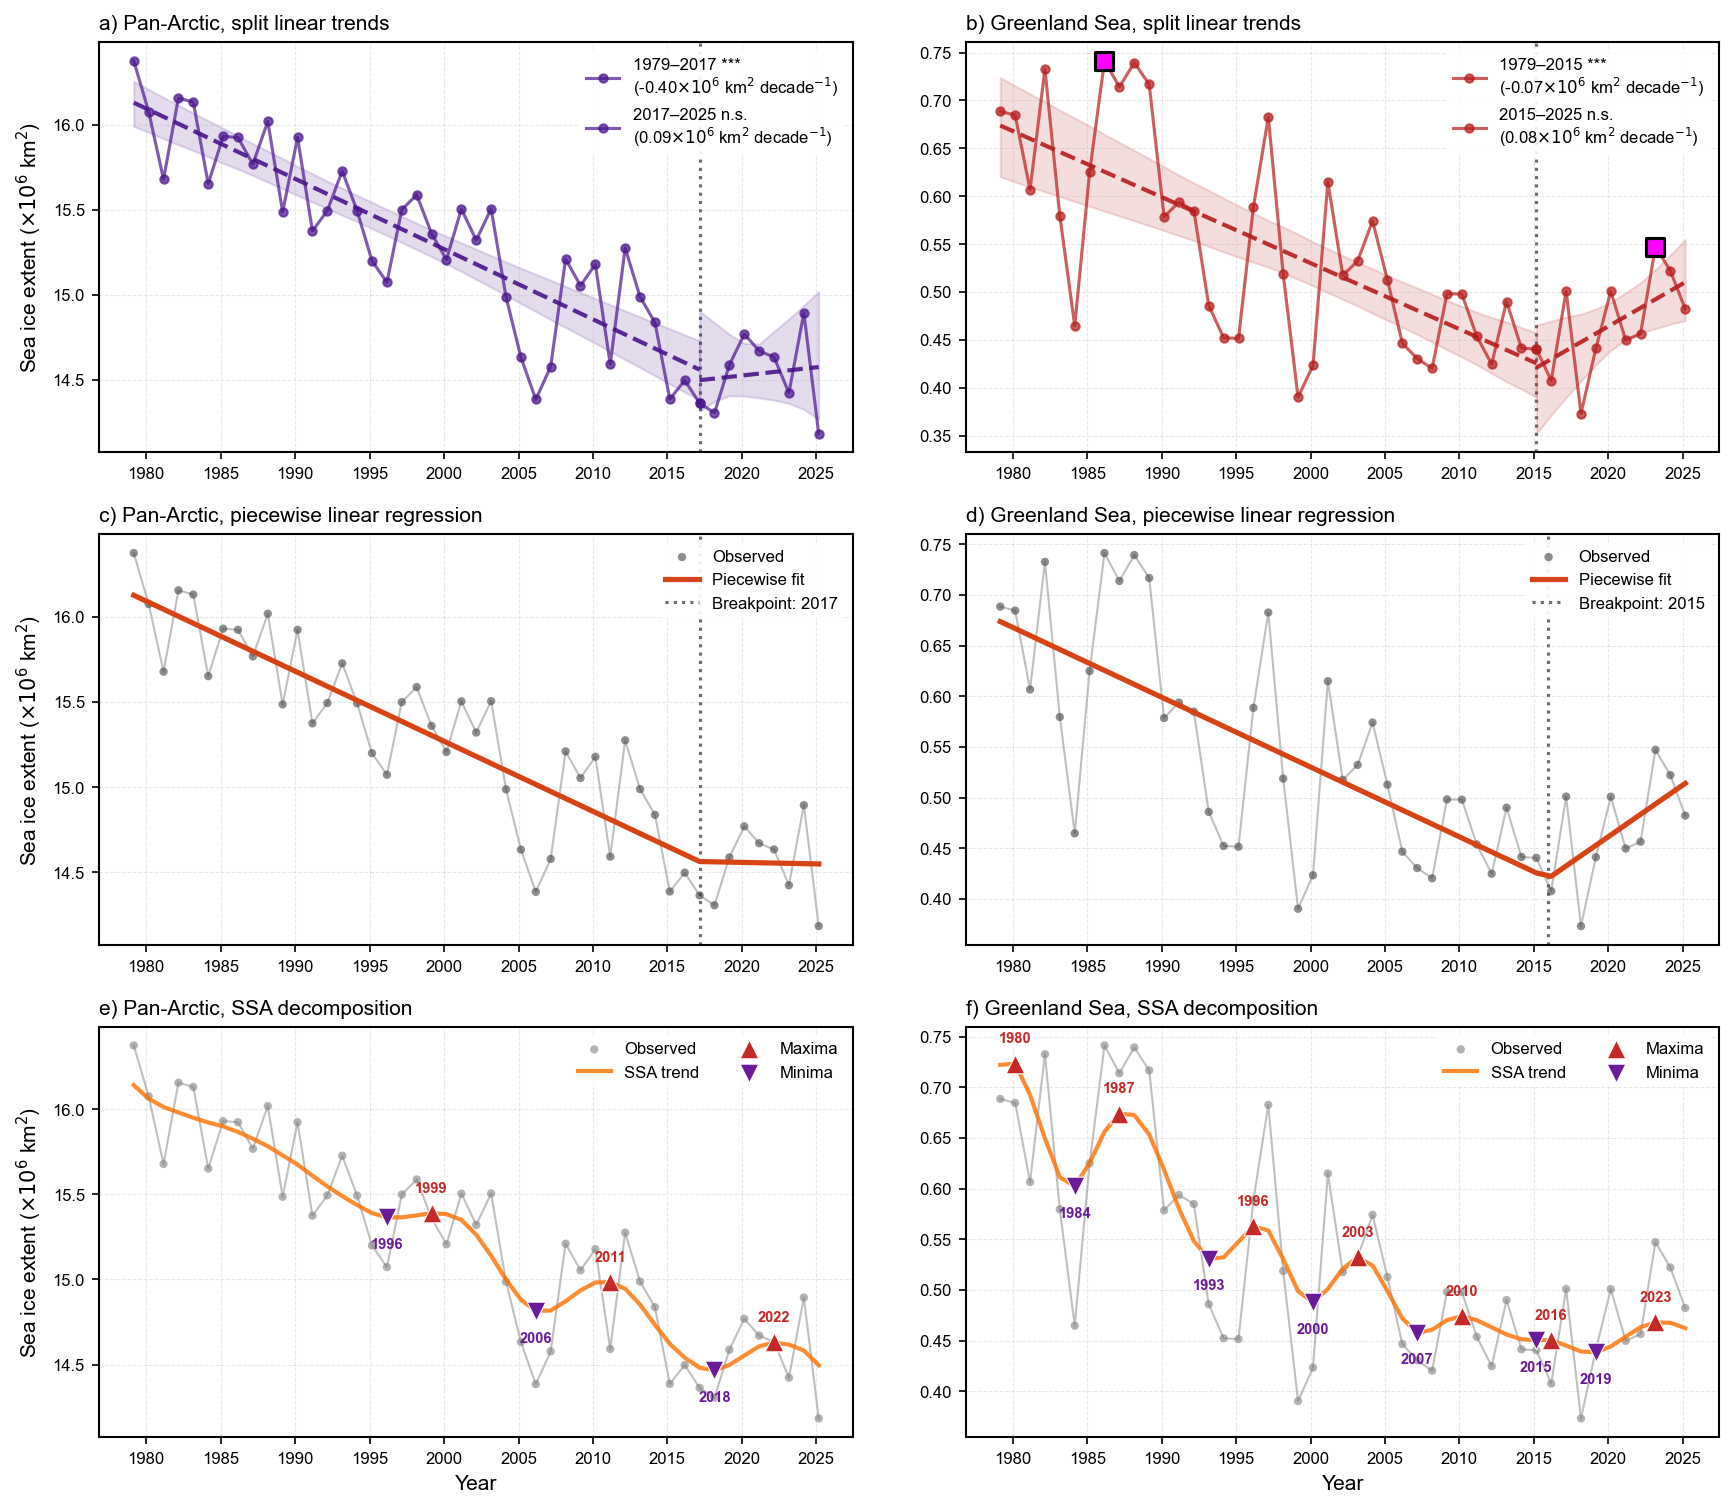


Configuration used:
  Season: winter (March)
  Uncertainty bands: True
  Rate annotations: False
  Confidence level: 95%
  Method: bootstrap


In [2]:
"""
Enhanced 6-panel figure: Wintertime Sea Ice Extent Trends
Pan-Arctic and Greenland Sea Regions

Features:
- Statistical significance testing (Mann-Kendall, t-test for trend differences)
- Optional uncertainty bands (bootstrap confidence intervals)
- Optional rate of change annotations
- Three analytical approaches per region

Author: Chris Barrell
"""

import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as dates
from matplotlib.patches import Rectangle, Polygon
import numpy as np
import pandas as pd
import pwlf
from pyts.decomposition import SingularSpectrumAnalysis
from scipy.signal import savgol_filter, find_peaks
from scipy import stats
import os
from typing import Dict, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION TOGGLES
# ============================================================================

CONFIG = {
    'show_uncertainty_bands': True,      # Toggle uncertainty bands on/off
    'show_rate_annotations': False,       # Toggle rate of change text boxes on/off
    'uncertainty_method': 'bootstrap',   # 'bootstrap' or 'analytical'
    'confidence_level': 0.95,            # Confidence level for intervals
    'n_bootstrap': 1000,                 # Number of bootstrap iterations
    'season': 'winter',                  # 'winter' (March) or 'summer' (September)
}

# ============================================================================
# STATISTICAL FUNCTIONS
# ============================================================================

def mann_kendall_test(x, y):
    """
    Mann-Kendall trend test for monotonic trends
    
    Parameters
    ----------
    x : array-like
        Time values (unused, for consistency)
    y : array-like
        Data values
        
    Returns
    -------
    dict
        tau: Kendall's tau
        p_value: Two-tailed p-value
        trend: 'increasing', 'decreasing', or 'no trend'
        significance: Significance level string
    """
    # Convert to numpy array if xarray
    y = np.asarray(y)
    
    n = len(y)
    s = 0
    
    for i in range(n-1):
        for j in range(i+1, n):
            s += np.sign(y[j] - y[i])
    
    # Variance calculation
    var_s = n * (n - 1) * (2 * n + 5) / 18
    
    # Z-statistic
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0
    
    # Two-tailed p-value
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    
    # Kendall's tau
    tau = s / (0.5 * n * (n - 1))
    
    # Determine trend
    if p_value < 0.05:
        if tau > 0:
            trend = 'increasing'
        else:
            trend = 'decreasing'
    else:
        trend = 'no trend'
    
    # Significance level
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'n.s.'
    
    return {
        'tau': tau,
        'p_value': p_value,
        'trend': trend,
        'significance': significance,
        'z_statistic': z
    }


def bootstrap_trend_ci(x, y, n_bootstrap=1000, confidence=0.95):
    """
    Bootstrap confidence intervals for linear trend
    
    Parameters
    ----------
    x : array-like
        Time values (matplotlib date numbers)
    y : array-like
        Data values
    n_bootstrap : int
        Number of bootstrap iterations
    confidence : float
        Confidence level (e.g., 0.95 for 95%)
        
    Returns
    -------
    dict
        lower_bound: Lower prediction band
        upper_bound: Upper prediction band
        trend_ci: (lower, upper) confidence interval for trend coefficient
    """
    # Convert to numpy arrays if xarray
    x = np.asarray(x)
    y = np.asarray(y)
    
    n = len(y)
    trends = []
    predictions = np.zeros((n_bootstrap, n))
    
    for i in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        x_boot = x[indices]
        y_boot = y[indices]
        
        # Fit linear model
        z = np.polyfit(x_boot, y_boot, 1)
        p = np.poly1d(z)
        
        # Store trend (per year)
        trend = (p(x[-1]) - p(x[0])) / len(x)
        trends.append(trend)
        
        # Store predictions at original x values
        predictions[i, :] = p(x)
    
    # Calculate percentiles
    alpha = 1 - confidence
    lower_percentile = (alpha / 2) * 100
    upper_percentile = (1 - alpha / 2) * 100
    
    lower_bound = np.percentile(predictions, lower_percentile, axis=0)
    upper_bound = np.percentile(predictions, upper_percentile, axis=0)
    
    trend_ci = (
        np.percentile(trends, lower_percentile),
        np.percentile(trends, upper_percentile)
    )
    
    return {
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'trend_ci': trend_ci
    }


def analytical_trend_ci(x, y, confidence=0.95):
    """
    Analytical confidence intervals for linear regression
    
    Parameters
    ----------
    x : array-like
        Time values (matplotlib date numbers)
    y : array-like
        Data values
    confidence : float
        Confidence level
        
    Returns
    -------
    dict
        lower_bound: Lower prediction band
        upper_bound: Upper prediction band
        trend_ci: (lower, upper) confidence interval for slope
        r_squared: Coefficient of determination
    """
    # Convert to numpy arrays if xarray
    x = np.asarray(x)
    y = np.asarray(y)
    
    n = len(y)
    
    # Fit linear model
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    y_fit = slope * x + intercept
    
    # Residuals
    residuals = y - y_fit
    mse = np.sum(residuals**2) / (n - 2)
    
    # Standard error of predictions
    x_mean = np.mean(x)
    se_line = np.sqrt(mse * (1/n + (x - x_mean)**2 / np.sum((x - x_mean)**2)))
    
    # t-statistic for confidence level
    t_val = stats.t.ppf((1 + confidence) / 2, n - 2)
    
    # Prediction bands
    margin = t_val * se_line
    lower_bound = y_fit - margin
    upper_bound = y_fit + margin
    
    # Confidence interval for slope (trend coefficient)
    se_slope = std_err
    trend_ci = (
        slope - t_val * se_slope,
        slope + t_val * se_slope
    )
    
    return {
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'trend_ci': trend_ci,
        'r_squared': r_value**2,
        'p_value': p_value,
        'slope': slope,
        'std_err': std_err
    }


def compare_trends(x1, y1, x2, y2):
    """
    Test if two trends are significantly different (Chow test)
    
    Parameters
    ----------
    x1, y1 : array-like
        First period data
    x2, y2 : array-like
        Second period data
        
    Returns
    -------
    dict
        f_statistic: F-statistic
        p_value: p-value
        significant: Boolean indicating if trends differ significantly
    """
    # Convert to numpy arrays if xarray
    x1 = np.asarray(x1)
    y1 = np.asarray(y1)
    x2 = np.asarray(x2)
    y2 = np.asarray(y2)
    
    # Fit separate models
    slope1, intercept1, _, _, _ = stats.linregress(x1, y1)
    slope2, intercept2, _, _, _ = stats.linregress(x2, y2)
    
    # Residuals
    y1_fit = slope1 * x1 + intercept1
    y2_fit = slope2 * x2 + intercept2
    rss1 = np.sum((y1 - y1_fit)**2)
    rss2 = np.sum((y2 - y2_fit)**2)
    rss_separate = rss1 + rss2
    
    # Fit pooled model
    x_pooled = np.concatenate([x1, x2])
    y_pooled = np.concatenate([y1, y2])
    slope_pooled, intercept_pooled, _, _, _ = stats.linregress(x_pooled, y_pooled)
    y_pooled_fit = slope_pooled * x_pooled + intercept_pooled
    rss_pooled = np.sum((y_pooled - y_pooled_fit)**2)
    
    # F-test
    n1, n2 = len(y1), len(y2)
    k = 2  # Number of parameters in each model
    f_statistic = ((rss_pooled - rss_separate) / k) / (rss_separate / (n1 + n2 - 2*k))
    
    # p-value
    p_value = 1 - stats.f.cdf(f_statistic, k, n1 + n2 - 2*k)
    
    return {
        'f_statistic': f_statistic,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'slope_diff': slope2 - slope1
    }


# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def get_trend(x, y):
    """Calculate linear trend with statistics"""
    # Convert to numpy arrays if xarray
    x = np.asarray(x)
    y = np.asarray(y)
    
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    trend = (p(x[-1]) - p(x[0])) / len(x)
    
    # Get full statistics
    stats_result = analytical_trend_ci(x, y)
    
    return p, trend, stats_result


def add_months(ds):
    """Add month coordinate to xarray dataset"""
    ds.coords['month'] = xr.DataArray(np.zeros(ds.time.shape), coords={'time': ds.time})
    for i, t in enumerate(ds.time):
        t = t.data
        month = t.astype('M8[M]').astype(int) % 12 + 1
        ds.coords['month'][i] = month
    return ds


def fetch_sie(region, sie_list):
    """Fetch sea ice extent data for specified region"""
    for sie in sie_list:
        if sie.name == region:
            return sie
    raise ValueError(f"Region '{region}' not found in sie_list")


def format_trend_label(period_str, trend_value, significance='', color=None):
    """Format trend label with significance"""
    sig_str = f' {significance}' if significance else ''
    return period_str + sig_str + '\n(' + f'{trend_value:.2f}' + r'$\times10^{6}$ km$^{2}$ decade$^{-1}$)'


def perform_ssa_analysis(data, times, window_fraction=0.15):
    """Perform SSA trend decomposition"""
    # Convert to numpy array if needed
    data = np.asarray(data)
    
    n = len(data)
    window_size = max(10, int(window_fraction * n))
    
    ssa = SingularSpectrumAnalysis(window_size=window_size, groups=None)
    X_ssa = ssa.fit_transform(data.reshape(1, -1))
    
    trend = X_ssa[0, 0] + X_ssa[0, 1]
    
    # Find peaks and troughs directly on SSA trend
    peaks, _ = find_peaks(trend, distance=int(0.05 * n))
    troughs, _ = find_peaks(-trend, distance=int(0.05 * n))
    
    return {
        'trend': trend,
        'peaks': peaks,
        'troughs': troughs
    }


def add_rate_annotation(ax, x_start, x_end, trend_value, y_pos, color, label=''):
    """
    Add rate of change annotation box
    
    Parameters
    ----------
    ax : matplotlib axis
    x_start, x_end : datetime64
        Start and end dates for annotation
    trend_value : float
        Trend value in units per year
    y_pos : float
        Vertical position for annotation (data coordinates)
    color : str
        Color for box
    label : str
        Additional label text
    """
    if not CONFIG['show_rate_annotations']:
        return
    
    # Convert trend to per decade
    trend_decade = trend_value * 10
    
    # Calculate position
    x_center = x_start + (x_end - x_start) / 2
    
    # Format text
    sign = '+' if trend_decade > 0 else ''
    text = sign + f'{trend_decade:.2f}' + '\n' + r'$\times10^{6}$ km$^{2}$ dec$^{-1}$'
    if label:
        text = label + '\n' + text
    
    # Add text box
    bbox_props = dict(boxstyle='round,pad=0.5', facecolor=color, 
                     alpha=0.15, edgecolor=color, linewidth=1.5)
    ax.text(x_center, y_pos, text, 
           bbox=bbox_props, fontsize=7, ha='center', va='center',
           fontweight='bold', color=color)


# ============================================================================
# STYLING CONFIGURATION
# ============================================================================

COLORS = {
    'arctic_early': '#4A148C',
    'arctic_late': '#7B1FA2',
    'arctic_trend': '#9C27B0',
    'gs_early': '#B71C1C',
    'gs_late': '#D32F2F',
    'gs_trend': '#E57373',
    'data': '#424242',
    'pwlr_fit': '#D84315',
    'breakpoint': '#263238',
    'ssa_original': '#78909C',
    'ssa_trend': '#FF6F00',
    'ssa_smooth': '#F57C00',
    'peaks': '#C62828',
    'troughs': '#6A1B9A'
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'legend.framealpha': 0.9,
    'axes.linewidth': 1.0,
    'grid.alpha': 0.3,
    'figure.dpi': 150
})

# ============================================================================
# DATA LOADING
# ============================================================================

print("Loading sea ice extent data...")
indir = '../osi-sea_ice_index/'
f_list = os.listdir(indir)

sie_list = []
for f in f_list:
    ds = xr.open_dataset(indir + f)
    ds_monthly = ds.drop_vars('area').resample(time='MS').mean()
    ds_monthly = add_months(ds_monthly)
    
    f_info = f.split('_')
    region = f_info[1]
    title_info = ds.title.split()
    for i, word in enumerate(title_info):
        if word == 'Ice':
            region_name = ' '.join(title_info[1:i-1])
            
    sie = ds_monthly.sie
    sie = sie.rename(region)
    sie.attrs['title'] = ds.title
    sie.attrs['region_name'] = region_name
    sie.attrs['summary'] = ds.summary
    sie_list.append(sie)

ds_nh = fetch_sie('nh', sie_list)
ds_gs = fetch_sie('fram', sie_list)

# Select season
if CONFIG['season'] == 'winter':
    season_month = 3
    season_name = 'March'
elif CONFIG['season'] == 'summer':
    season_month = 9
    season_name = 'September'
else:
    raise ValueError("CONFIG['season'] must be 'winter' or 'summer'")

print(f"Season: {season_name} (month {season_month})")

# ============================================================================
# CREATE FIGURE
# ============================================================================

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(3, 2, hspace=0.2, wspace=0.15, 
                      left=0.08, right=0.98, top=0.98, bottom=0.05)

axes = []
for i in range(3):
    for j in range(2):
        ax = fig.add_subplot(gs[i, j])
        axes.append(ax)

# ============================================================================
# ROW 1: MANUAL SPLIT LINEAR TRENDS WITH STATISTICS
# ============================================================================

print("\n" + "="*70)
print("ROW 1: SPLIT LINEAR TRENDS WITH STATISTICAL TESTING")
print("="*70)

# --- Panel (a): Arctic ---
ax = axes[0]
print(f"\nPanel (a): Pan-Arctic {season_name}")

# Arctic breakpoint (adjust based on season if needed)
if CONFIG['season'] == 'winter':
    break_year = '2017'
else:  # summer
    break_year = '2012'

split_1 = slice('1979', break_year)
split_2 = slice(break_year, '2025')

x_1 = ds_nh.time.sel(time=split_1).where(ds_nh.month == season_month, drop=True)
x_num_1 = dates.date2num(x_1)
x_2 = ds_nh.time.sel(time=split_2).where(ds_nh.month == season_month, drop=True)
x_num_2 = dates.date2num(x_2)

y_1 = ds_nh.sel(time=split_1).where(ds_nh.month == season_month, drop=True)
p_1, trend_1, stats_1 = get_trend(x_num_1, y_1)
y_2 = ds_nh.sel(time=split_2).where(ds_nh.month == season_month, drop=True)
p_2, trend_2, stats_2 = get_trend(x_num_2, y_2)

# Mann-Kendall test
mk_1 = mann_kendall_test(x_num_1, y_1)
mk_2 = mann_kendall_test(x_num_2, y_2)

# Compare trends
trend_comparison = compare_trends(x_num_1, y_1, x_num_2, y_2)

# Print statistics
print(f"Period 1 (1979-{break_year}):")
print(f"  Trend: {trend_1*10:.3f} ×10⁶ km²/decade")
print(f"  R²: {stats_1['r_squared']:.3f}")
print(f"  p-value: {stats_1['p_value']:.4f}")
print(f"  Mann-Kendall: τ={mk_1['tau']:.3f}, p={mk_1['p_value']:.4f} {mk_1['significance']}")

print(f"Period 2 ({break_year}-2024):")
print(f"  Trend: {trend_2*10:.3f} ×10⁶ km²/decade")
print(f"  R²: {stats_2['r_squared']:.3f}")
print(f"  p-value: {stats_2['p_value']:.4f}")
print(f"  Mann-Kendall: τ={mk_2['tau']:.3f}, p={mk_2['p_value']:.4f} {mk_2['significance']}")

print(f"Trend difference test:")
print(f"  F-statistic: {trend_comparison['f_statistic']:.3f}")
print(f"  p-value: {trend_comparison['p_value']:.4f}")
print(f"  Significantly different: {trend_comparison['significant']}")

# Uncertainty bands
if CONFIG['show_uncertainty_bands']:
    if CONFIG['uncertainty_method'] == 'bootstrap':
        ci_1 = bootstrap_trend_ci(x_num_1, y_1, 
                                  n_bootstrap=CONFIG['n_bootstrap'],
                                  confidence=CONFIG['confidence_level'])
        ci_2 = bootstrap_trend_ci(x_num_2, y_2,
                                  n_bootstrap=CONFIG['n_bootstrap'],
                                  confidence=CONFIG['confidence_level'])
    else:
        ci_1 = analytical_trend_ci(x_num_1, y_1, confidence=CONFIG['confidence_level'])
        ci_2 = analytical_trend_ci(x_num_2, y_2, confidence=CONFIG['confidence_level'])
    
    ax.fill_between(x_1, ci_1['lower_bound'], ci_1['upper_bound'],
                    color=COLORS['arctic_early'], alpha=0.15, zorder=1)
    ax.fill_between(x_2, ci_2['lower_bound'], ci_2['upper_bound'],
                    color=COLORS['arctic_early'], alpha=0.15, zorder=1)

# Plot - use single color throughout
ax.plot(x_1, y_1, marker='o', markersize=4, linestyle='-',
        color=COLORS['arctic_early'], linewidth=1.5, alpha=0.7,
        label=format_trend_label(f'1979–{int(break_year)}', trend_1 * 10, 
                                mk_1['significance'], COLORS['arctic_early']))
ax.plot(x_1, p_1(x_num_1), color=COLORS['arctic_early'], 
        linestyle='--', linewidth=2, alpha=0.9)

ax.plot(x_2, y_2, marker='o', markersize=4, linestyle='-',
        color=COLORS['arctic_early'], linewidth=1.5, alpha=0.7,
        label=format_trend_label(f'{break_year}–2025', trend_2 * 10, 
                                mk_2['significance'], COLORS['arctic_early']))
ax.plot(x_2, p_2(x_num_2), color=COLORS['arctic_early'], 
        linestyle='--', linewidth=2, alpha=0.9)

# Rate annotations
y_range = ax.get_ylim()
y_mid = y_range[0] + 0.7 * (y_range[1] - y_range[0])
add_rate_annotation(ax, x_1[0].values, x_1[-1].values, trend_1, 
                   y_mid, COLORS['arctic_early'])
add_rate_annotation(ax, x_2[0].values, x_2[-1].values, trend_2, 
                   y_mid - 0.5, COLORS['arctic_early'])

ax.axvline(x=np.datetime64(f'{break_year}-{season_month:02d}-01'), 
           color=COLORS['breakpoint'], linestyle=':', linewidth=1.5, alpha=0.7, zorder=0)
ax.set_ylabel(r'Sea ice extent ($\times10^{6}$ km$^{2}$)')
ax.set_title('a) Pan-Arctic, split linear trends', loc='left')
ax.legend(loc='upper right', frameon=True, edgecolor='none')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# --- Panel (b): Greenland Sea ---
ax = axes[1]
print(f"\nPanel (b): Greenland Sea {season_name}")

if CONFIG['season'] == 'winter':
    break_year = '2015'
else:  # summer
    break_year = '2012'

split_1 = slice('1979', break_year)
split_2 = slice(break_year, '2025')

x_1 = ds_gs.time.sel(time=split_1).where(ds_gs.month == season_month, drop=True)
x_num_1 = dates.date2num(x_1)
x_2 = ds_gs.time.sel(time=split_2).where(ds_gs.month == season_month, drop=True)
x_num_2 = dates.date2num(x_2)

y_1 = ds_gs.sel(time=split_1).where(ds_gs.month == season_month, drop=True)
p_1, trend_1, stats_1 = get_trend(x_num_1, y_1)
y_2 = ds_gs.sel(time=split_2).where(ds_gs.month == season_month, drop=True)
p_2, trend_2, stats_2 = get_trend(x_num_2, y_2)

mk_1 = mann_kendall_test(x_num_1, y_1)
mk_2 = mann_kendall_test(x_num_2, y_2)
trend_comparison = compare_trends(x_num_1, y_1, x_num_2, y_2)

print(f"Period 1 (1979-{break_year}):")
print(f"  Trend: {trend_1*10:.3f} ×10⁶ km²/decade")
print(f"  Mann-Kendall: τ={mk_1['tau']:.3f}, p={mk_1['p_value']:.4f} {mk_1['significance']}")
print(f"Period 2 ({break_year}-2025):")
print(f"  Trend: {trend_2*10:.3f} ×10⁶ km²/decade")
print(f"  Mann-Kendall: τ={mk_2['tau']:.3f}, p={mk_2['p_value']:.4f} {mk_2['significance']}")
print(f"Trends significantly different: {trend_comparison['significant']} (p={trend_comparison['p_value']:.4f})")

if CONFIG['show_uncertainty_bands']:
    if CONFIG['uncertainty_method'] == 'bootstrap':
        ci_1 = bootstrap_trend_ci(x_num_1, y_1, 
                                  n_bootstrap=CONFIG['n_bootstrap'],
                                  confidence=CONFIG['confidence_level'])
        ci_2 = bootstrap_trend_ci(x_num_2, y_2,
                                  n_bootstrap=CONFIG['n_bootstrap'],
                                  confidence=CONFIG['confidence_level'])
    else:
        ci_1 = analytical_trend_ci(x_num_1, y_1, confidence=CONFIG['confidence_level'])
        ci_2 = analytical_trend_ci(x_num_2, y_2, confidence=CONFIG['confidence_level'])
    
    ax.fill_between(x_1, ci_1['lower_bound'], ci_1['upper_bound'],
                    color=COLORS['gs_early'], alpha=0.15, zorder=1)
    ax.fill_between(x_2, ci_2['lower_bound'], ci_2['upper_bound'],
                    color=COLORS['gs_early'], alpha=0.15, zorder=1)

# Plot - use single color throughout
ax.plot(x_1, y_1, marker='o', markersize=4, linestyle='-',
        color=COLORS['gs_early'], linewidth=1.5, alpha=0.7,
        label=format_trend_label(f'1979–{int(break_year)}', trend_1 * 10, 
                                mk_1['significance'], COLORS['gs_early']))
ax.plot(x_1, p_1(x_num_1), color=COLORS['gs_early'], 
        linestyle='--', linewidth=2, alpha=0.9)

ax.plot(x_2, y_2, marker='o', markersize=4, linestyle='-',
        color=COLORS['gs_early'], linewidth=1.5, alpha=0.7,
        label=format_trend_label(f'{break_year}–2025', trend_2 * 10, 
                                mk_2['significance'], COLORS['gs_early']))
ax.plot(x_2, p_2(x_num_2), color=COLORS['gs_early'], 
        linestyle='--', linewidth=2, alpha=0.9)

# Find and highlight maximum sea ice extent for each period
# Period 1
max_idx_1 = np.argmax(y_1.values)
max_year_1 = x_1[max_idx_1]
max_sie_1 = y_1.values[max_idx_1]
ax.scatter(max_year_1, max_sie_1, marker='s', s=80, 
          color='magenta', edgecolor='black', linewidth=1.5, 
          zorder=10) #, label=f'Max: {str(max_year_1.data)[0:4]}'

# Period 2
max_idx_2 = np.argmax(y_2.values)
max_year_2 = x_2[max_idx_2]
max_sie_2 = y_2.values[max_idx_2]
ax.scatter(max_year_2, max_sie_2, marker='s', s=80, 
          color='magenta', edgecolor='black', linewidth=1.5, 
          zorder=10)

y_range = ax.get_ylim()
y_mid = y_range[0] + 0.7 * (y_range[1] - y_range[0])
add_rate_annotation(ax, x_1[0].values, x_1[-1].values, trend_1, 
                   y_mid, COLORS['gs_early'])
add_rate_annotation(ax, x_2[0].values, x_2[-1].values, trend_2, 
                   y_mid * 0.85, COLORS['gs_early'])

ax.axvline(x=np.datetime64(f'{break_year}-{season_month:02d}-01'), 
           color=COLORS['breakpoint'], linestyle=':', linewidth=1.5, alpha=0.7, zorder=0)
ax.set_title('b) Greenland Sea, split linear trends', loc='left')
ax.legend(loc='upper right', frameon=True, edgecolor='none')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# ============================================================================
# ROW 2: PIECEWISE LINEAR REGRESSION
# ============================================================================

print("\n" + "="*70)
print("ROW 2: PIECEWISE LINEAR REGRESSION")
print("="*70)

# --- Panel (c): Arctic ---
ax = axes[2]
print(f"\nPanel (c): Pan-Arctic {season_name} PWLR")

x_data = ds_nh.time.where(ds_nh.month == season_month, drop=True)
x_num = dates.date2num(x_data)
y_data = ds_nh.where(ds_nh.month == season_month, drop=True)

model = pwlf.PiecewiseLinFit(x_num, y_data)
breaks = model.fit(2)
y_hat = model.predict(x_num)
break_date = dates.num2date(breaks[1])
np_break_date = np.datetime64(break_date)

# Calculate segment statistics
seg1_mask = x_num <= breaks[1]
seg2_mask = x_num >= breaks[1]
seg1_stats = analytical_trend_ci(x_num[seg1_mask], y_data[seg1_mask])
seg2_stats = analytical_trend_ci(x_num[seg2_mask], y_data[seg2_mask])

print(f"Automated breakpoint: {str(np_break_date)[0:4]}")
print(f"Segment 1 R²: {seg1_stats['r_squared']:.3f}, p: {seg1_stats['p_value']:.4f}")
print(f"Segment 2 R²: {seg2_stats['r_squared']:.3f}, p: {seg2_stats['p_value']:.4f}")

# Plot grey line connecting points
ax.plot(x_data, y_data, color='#808080', linewidth=1, alpha=0.5, zorder=1)
# Plot scatter points on top
ax.scatter(x_data, y_data, s=16, color=COLORS['data'], alpha=0.6, 
           label='Observed', zorder=2, edgecolors='none')
# Plot piecewise fit
ax.plot(x_data, y_hat, color=COLORS['pwlr_fit'], linewidth=2.5, 
        label='Piecewise fit', zorder=3)
ax.axvline(x=np_break_date, color=COLORS['breakpoint'], linestyle=':', 
           linewidth=1.5, alpha=0.7, 
           label=f"Breakpoint: {str(np_break_date)[0:4]}", zorder=1)

ax.set_ylabel(r'Sea ice extent ($\times10^{6}$ km$^{2}$)')
ax.set_title('c) Pan-Arctic, piecewise linear regression', loc='left')
ax.legend(loc='upper right', frameon=True, edgecolor='none')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# --- Panel (d): Greenland Sea ---
ax = axes[3]
print(f"\nPanel (d): Greenland Sea {season_name} PWLR")

x_data = ds_gs.time.where(ds_gs.month == season_month, drop=True)
x_num = dates.date2num(x_data)
y_data = ds_gs.where(ds_gs.month == season_month, drop=True)

model = pwlf.PiecewiseLinFit(x_num, y_data)
breaks = model.fit(2)
y_hat = model.predict(x_num)
break_date = dates.num2date(breaks[1])
np_break_date = np.datetime64(break_date)

seg1_mask = x_num <= breaks[1]
seg2_mask = x_num >= breaks[1]
seg1_stats = analytical_trend_ci(x_num[seg1_mask], y_data[seg1_mask])
seg2_stats = analytical_trend_ci(x_num[seg2_mask], y_data[seg2_mask])

print(f"Automated breakpoint: {str(np_break_date)[0:4]}")
print(f"Segment 1 R²: {seg1_stats['r_squared']:.3f}, p: {seg1_stats['p_value']:.4f}")
print(f"Segment 2 R²: {seg2_stats['r_squared']:.3f}, p: {seg2_stats['p_value']:.4f}")

# Plot grey line connecting points
ax.plot(x_data, y_data, color='#808080', linewidth=1, alpha=0.5, zorder=1)
# Plot scatter points on top
ax.scatter(x_data, y_data, s=16, color=COLORS['data'], alpha=0.6, 
           label='Observed', zorder=2, edgecolors='none')
# Plot piecewise fit
ax.plot(x_data, y_hat, color=COLORS['pwlr_fit'], linewidth=2.5, 
        label='Piecewise fit', zorder=3)
ax.axvline(x=np_break_date, color=COLORS['breakpoint'], linestyle=':', 
           linewidth=1.5, alpha=0.7,
           label=f"Breakpoint: {str(np_break_date)[0:4]}", zorder=1)

ax.set_title('d) Greenland Sea, piecewise linear regression', loc='left')
ax.legend(loc='upper right', frameon=True, edgecolor='none')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# ============================================================================
# ROW 3: SSA TREND DECOMPOSITION
# ============================================================================

print("\n" + "="*70)
print("ROW 3: SSA TREND DECOMPOSITION")
print("="*70)

# --- Panel (e): Arctic ---
ax = axes[4]
print(f"\nPanel (e): Pan-Arctic {season_name} SSA")

x_data = ds_nh.time.where(ds_nh.month == season_month, drop=True)
y_data = ds_nh.where(ds_nh.month == season_month, drop=True)

ssa_results = perform_ssa_analysis(y_data.values, x_data)

# Plot grey line and dots for observed data
ax.plot(x_data, y_data, color='#808080', linewidth=1, alpha=0.5, zorder=1)
ax.scatter(x_data, y_data, s=16, color='#808080', alpha=0.6, 
           label='Observed', zorder=2, edgecolors='none')
# Plot SSA trend
ax.plot(x_data, ssa_results['trend'], color=COLORS['ssa_trend'], 
        linewidth=2, label='SSA trend', alpha=0.8, zorder=3)

peaks = ssa_results['peaks']
troughs = ssa_results['troughs']
ax.scatter(x_data[peaks], ssa_results['trend'][peaks], 
          marker='^', s=80, color=COLORS['peaks'], 
          label='Maxima', zorder=5, edgecolor='white', linewidth=0.5)
ax.scatter(x_data[troughs], ssa_results['trend'][troughs], 
          marker='v', s=80, color=COLORS['troughs'], 
          label='Minima', zorder=5, edgecolor='white', linewidth=0.5)

for i in peaks:
    ax.annotate(f"{str(x_data[i].data)[0:4]}", 
               (x_data[i], ssa_results['trend'][i]),
               textcoords="offset points", xytext=(0, 10), 
               ha='center', fontsize=7, color=COLORS['peaks'], 
               fontweight='bold')
for i in troughs:
    ax.annotate(f"{str(x_data[i].data)[0:4]}", 
               (x_data[i], ssa_results['trend'][i]),
               textcoords="offset points", xytext=(0, -15), 
               ha='center', fontsize=7, color=COLORS['troughs'], 
               fontweight='bold')

print(f"Number of peaks detected: {len(peaks)}")
print(f"Number of troughs detected: {len(troughs)}")

ax.set_xlabel('Year')
ax.set_ylabel(r'Sea ice extent ($\times10^{6}$ km$^{2}$)')
ax.set_title('e) Pan-Arctic, SSA decomposition', loc='left')
ax.legend(loc='upper right', frameon=True, edgecolor='none', ncol=2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# --- Panel (f): Greenland Sea ---
ax = axes[5]
print(f"\nPanel (f): Greenland Sea {season_name} SSA")

x_data = ds_gs.time.where(ds_gs.month == season_month, drop=True)
y_data = ds_gs.where(ds_gs.month == season_month, drop=True)

ssa_results = perform_ssa_analysis(y_data.values, x_data)

# Plot grey line and dots for observed data
ax.plot(x_data, y_data, color='#808080', linewidth=1, alpha=0.5, zorder=1)
ax.scatter(x_data, y_data, s=16, color='#808080', alpha=0.6, 
           label='Observed', zorder=2, edgecolors='none')
# Plot SSA trend
ax.plot(x_data, ssa_results['trend'], color=COLORS['ssa_trend'], 
        linewidth=2, label='SSA trend', alpha=0.8, zorder=3)

peaks = ssa_results['peaks']
troughs = ssa_results['troughs']
ax.scatter(x_data[peaks], ssa_results['trend'][peaks], 
          marker='^', s=80, color=COLORS['peaks'], 
          label='Maxima', zorder=5, edgecolor='white', linewidth=0.5)
ax.scatter(x_data[troughs], ssa_results['trend'][troughs], 
          marker='v', s=80, color=COLORS['troughs'], 
          label='Minima', zorder=5, edgecolor='white', linewidth=0.5)

for i in peaks:
    ax.annotate(f"{str(x_data[i].data)[0:4]}", 
               (x_data[i], ssa_results['trend'][i]),
               textcoords="offset points", xytext=(0, 10), 
               ha='center', fontsize=7, color=COLORS['peaks'], 
               fontweight='bold')
for i in troughs:
    ax.annotate(f"{str(x_data[i].data)[0:4]}", 
               (x_data[i], ssa_results['trend'][i]),
               textcoords="offset points", xytext=(0, -15), 
               ha='center', fontsize=7, color=COLORS['troughs'], 
               fontweight='bold')

print(f"Number of peaks detected: {len(peaks)}")
print(f"Number of troughs detected: {len(troughs)}")

ax.set_xlabel('Year')
ax.set_title('f) Greenland Sea, SSA decomposition', loc='left')
ax.legend(loc='upper right', frameon=True, edgecolor='none', ncol=2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# ============================================================================
# FINALIZE AND SAVE
# ============================================================================

output_dir = './sie_trends'
os.makedirs(output_dir, exist_ok=True)

# Generate filename based on configuration
config_suffix = []
if CONFIG['show_uncertainty_bands']:
    config_suffix.append('CI')
if CONFIG['show_rate_annotations']:
    config_suffix.append('rates')
suffix_str = '_' + '_'.join(config_suffix) if config_suffix else ''

output_path = f"{output_dir}/Fig2_SIE_trends_{CONFIG['season']}_6panel{suffix_str}.png"
fig.savefig(output_path, dpi=600, bbox_inches='tight', facecolor='white')
print(f"\n{'='*70}")
print(f"Figure saved to: {output_path}")
print(f"{'='*70}\n")

plt.show()

print("\nConfiguration used:")
print(f"  Season: {CONFIG['season']} ({season_name})")
print(f"  Uncertainty bands: {CONFIG['show_uncertainty_bands']}")
print(f"  Rate annotations: {CONFIG['show_rate_annotations']}")
print(f"  Confidence level: {CONFIG['confidence_level']*100:.0f}%")
if CONFIG['show_uncertainty_bands']:
    print(f"  Method: {CONFIG['uncertainty_method']}")